# Salt Surface Forcing

We want to find sensible values for the salinity flux forcing. We try two approaches
A) Salt Flux from Surface Salinity Change in the MEOP Profiles
B) Salt Flux from estimated sea ice growth 

##  Import Packages

In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import xmitgcm.utils
import gsw as gsw
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import mat73 # for loading .mat files version >= 7.3

## Load ERA5 Data

In [2]:
c_max = 0.99
path = "../observations_reanalysis/"
filename = "ERA5_seaice_netHeat_leadHeat_cmax"+str(c_max)+".nc"
df_seaice = xr.open_dataset(path+filename)

sh: getfattr: command not found


## Load MEOP Data

In [3]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In [4]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

- data1: metadata of the supercooled profiles
- data1_other: metadata non-supercooled profiles
- data2: the supercooled profiles

### Add Datetime

In [5]:
# add datetime variable
zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts with 1 at 0000-01-01 and includes a leap year in year 0
datetimes = [
    zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = pd.Series(np.array(datetimes))

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = pd.Series(np.array(datetimes_other))


### Filter for Seal 9900109

In [6]:
mask_9900109 = (data1["id"] == 9900109)

data1_9900109 = {key: data1[key][mask_9900109] for key in data1.keys()}
data2_9900109 = {key: data2[key][:,mask_9900109] for key in data2.keys()}

mask_other_9900109 = (data1_other["id"] == 9900109)
data1_other_9900109 = {key: data1_other[key][mask_other_9900109] for key in data1_other.keys()}

## Select Cluster

Select July cluster from 2008-07-16 08 to 2008-07-19 12 for MEOP data

In [7]:
start = datetime(2008,7,16,8)
end = datetime(2008,7,19,12)

mask = (data1_9900109['datetimes'] > start) & (data1_9900109['datetimes'] < end)

data1_cluster = pd.DataFrame(data1_9900109)[mask]

data2_cluster = {key: data2_9900109[key][:, mask]
     for key in ["dpth",'dpth_mid',"s"]} 
data2_cluster

{'dpth': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1050, 10)),
 'dpth_mid': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1049, 10)),
 's': array([[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]], shape=(1050, 10))}

Crop to corresponding ERA5 grid cells and also crop temporally

In [8]:
print(max(data1_cluster.lat))
print(min(data1_cluster.lat))
print(max(data1_cluster.lon))
print(min(data1_cluster.lon))
lon = data1_cluster.lat

-60.3334
-60.6139
9.031
8.5719


In [9]:
start_date = pd.to_datetime("2008-06-28 00:00")
end_date = pd.to_datetime("2008-08-05 23:59")

lat = data1_cluster.lat
lon = data1_cluster.lon

# crop spatially and temporally to cluster
df_seaice_cluster = df_seaice.sel(latitude = slice(max(lat)+0.125,min(lat)-0.125), 
                                  longitude = slice(min(lon)-0.125,max(lon)+0.125),
                                  time = slice(start_date, end_date))

df_seaice_cluster

<xarray.Dataset> Size: 82kB
Dimensions:                (time: 936, latitude: 2, longitude: 3)
Coordinates:
  * time                   (time) datetime64[ns] 7kB 2008-06-28 ... 2008-08-0...
  * latitude               (latitude) float64 16B -60.25 -60.5
  * longitude              (longitude) float64 24B 8.5 8.75 9.0
    number                 int64 8B ...
    step                   timedelta64[ns] 8B ...
    surface                float64 8B ...
    valid_time             (time) datetime64[ns] 7kB ...
Data variables:
    siconc                 (time, latitude, longitude) float32 22kB ...
    surface_net_heat_flux  (time, latitude, longitude) float32 22kB ...
    open_water_heatflux    (time, latitude, longitude) float32 22kB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-03T10:36 GRIB to CDM+CF via cfgrib-0.9.1...

## Calculate Salt Flux

### A) Calculate Salt Flux from MEOP Salinity Changes

In [65]:
print(f"Minimum layer thickness: {np.nanmin(data2_cluster['dpth_mid'][1:,:]-data2_cluster['dpth_mid'][:-1,:]):.2f}")
print(f"Maximum layer thickness: {np.nanmax(data2_cluster['dpth_mid'][1:,:]-data2_cluster['dpth_mid'][:-1,:]):.2f}")

Minimum layer thickness: 0.99
Maximum layer thickness: 0.99


In [133]:
# Salt Flux based on whole profile depth
s_mean = np.nanmean(data2_cluster['s'], axis=0) # unit PSU, similar to g/kg
max_depth = np.nanmax(data2_cluster["dpth"])
total_salt = s_mean * max_depth * 1000# water column salt content g/m^2
total_salt_change = total_salt[1:]-total_salt[0:-1] # g/m^2/delta t
time_diff = (cluster_data1["dates"].values[1:]-cluster_data1["dates"].values[0:-1])*24*3600 # delta t in s

print("Salt flux between profiles based on whole 800m deep profile (g/(m^2s)):")
print(*np.round(total_salt_change/time_diff,2))

Salt flux between profiles based on whole 800m deep profile (g/(m^2s)):
-0.14 0.02 1.7 -0.29 -0.88 0.12 -3.47 -5.33 7.0


In [140]:
# Salt Flux based on upper XXXm
# to be improved: PSU->g/kg; water density
max_depth = 130
s_mean = np.nanmean(data2_cluster['s'][0:max_depth,:], axis=0) # unit PSU, similar to g/kg
total_salt = s_mean * max_depth * 1000# water column salt content g/m^2
total_salt_change = total_salt[1:]-total_salt[0:-1] # g/m^2/delta t
time_diff = (cluster_data1["dates"].values[1:]-cluster_data1["dates"].values[0:-1])*24*3600 # delta t in s

print(f"Salt flux between profiles based on upper {max_depth}m [g/(m^2 s)]:")
print(*np.round(total_salt_change/time_diff,2))
print("Mean Value:")
print(f"{np.mean(total_salt_change/time_diff):.2f}")

Salt flux between profiles based on upper 130m [g/(m^2 s)]:
-0.02 -0.06 0.61 -0.3 -0.22 0.07 0.1 -0.3 0.35
Mean Value:
0.03


=> Let's take 0.03 g/(m^2 s) as a starting point.

### B) Calculate Salt Flux from Estimated Sea Ice Growth

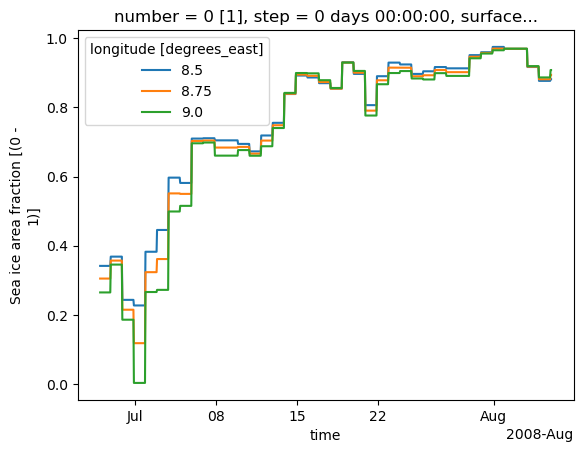

In [66]:
df_seaice_cluster.isel(latitude =0).siconc.plot.line(x = "time")

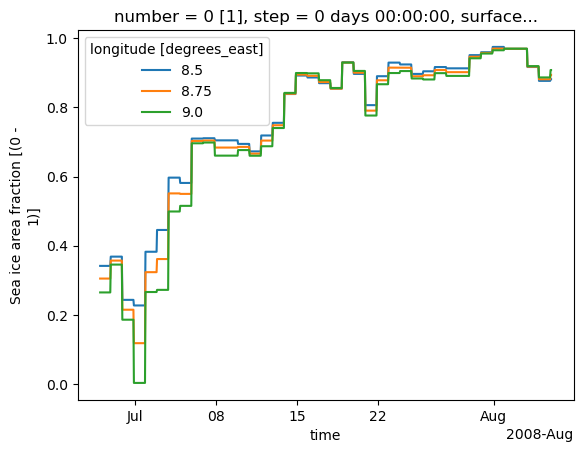

In [28]:
df_seaice_cluster.isel(latitude =0).siconc.plot.line(x = "time")

If over time $\Delta t $ the sea ice concentration grows from $\left(c=0, h_{ice} = 0\right)$ to $\left(c=1, h_{ice} = \Delta h_{ice}\right)$, the resulting salinity flux is

$$ F_S = \sigma  \rho_{ice}  \frac{\Delta h_{ice}}{\Delta t}$$

(If instead, the ice thickness $h_{ice}$ stays constant, but the sea ice concentration increases by $\Delta c$, then 
$ F_S = \sigma \rho_{ice}  \frac{\Delta m_{ice}}{\Delta t} = \sigma \frac{h_{ice} \Delta c}{\Delta t}  $)


,final h_ice (m),resulting F_S (g/m^2s)
0,0.0,0.000000
1,0.1,0.001008
2,0.2,0.002016
3,0.3,0.003024
4,0.4,0.004032
5,0.5,0.005040
6,0.6,0.006048
7,0.7,0.007056
8,0.8,0.008065
9,0.9,0.009073


<Axes: xlabel='final h_ice (m)'>

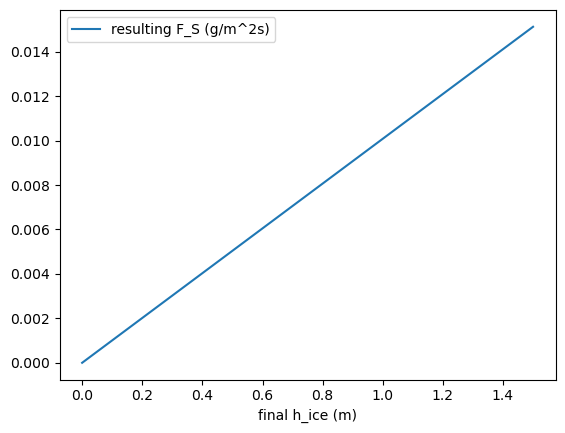

In [11]:
def salt_flux(h_ice, delta_t, sigma, rho_ice):
    '''Salt flux based on overgrowth'''
    F_s = sigma * rho_ice * h_ice / delta_t
    return F_s

h_ice = np.linspace(0,1.5,16)

sigma = 30 # salinity difference between sea ice and sea water (g/kg)
rho_ice = 900 # sea ice density (kg/m^3)
delta_t = 31*24*3600

F_s = salt_flux(h_ice = h_ice, delta_t = delta_t, sigma = sigma, rho_ice = rho_ice)

df = pd.DataFrame({
    'final h_ice (m)': h_ice,
    'resulting F_S (g/m^2s)': F_s
})

display(df) 

df.plot(x = 'final h_ice (m)')

## Write Binary for Lead

In [2]:
salt_flux_val = -0.03
salt_flux_const = np.zeros((36,66,594))
salt_flux_const[:,:,285:310] = salt_flux_val

# write binary
out_filename = "bin_forc_SA_36x66x594_100m_lead_const_-0.03.bin"
xmitgcm.utils.write_to_binary(salt_flux_const.flatten(order='C'), '../../MITgcm/so_plumes/input/' + out_filename)

In [ ]:
rowans_lead_name = "bin_forc_Q_36x66x594_100m_lead"

## Compare with Rowan's

In [5]:
# import Rowan's forcing field
rowans_lead_name = "bin_forc_SA_36x66x594_100m_lead_037"
r_filename = rowans_lead_name + ".bin"
rowans_salt_flux= xmitgcm.utils.read_raw_data('../../MITgcm/so_plumes/input/' + r_filename, shape=(36,66,594), dtype=np.dtype('>f4') ) # shape is (time, X, Y)

In [7]:
np.min(rowans_salt_flux)

np.float32(-0.2606435)

In [8]:
np.max(rowans_salt_flux)

np.float32(0.0)

## MIZ

### MIZ without buffer zone

In [9]:
Nx = 50 # east-west
Ny = 100 # north south
t = 24*2 # forcing period in h
ice_edge = int(Ny/2) # location of ice edge
S_const = -0.016

S_MIZ = np.zeros((Nx,Ny,t)) # if flattening in F-order this should be the correct shape
S_MIZ[:,0:ice_edge,:] = S_const

# write binary
out_filename = "bin_forc_SA_" + f"Nx{Nx}_Ny{Ny}_t{t}_{S_const}.bin"
xmitgcm.utils.write_to_binary(S_MIZ.flatten(order='F'), '../../MITgcm/so_plumes/binaries/' + out_filename)
print(out_filename)

bin_forc_SA_Nx50_Ny100_t48_-0.016.bin


### MIZ with North buffer zone

In [3]:
Nx = 50 # east-west
Ny = 100 # north south
t = 24*2 # forcing period in h
ice_edge = 60 # location of ice edge
buffer_size = 10 # length of buffer zone with no forcing in the north
S_const = -0.008

S_MIZ = np.zeros((Nx,Ny,t)) # if flattening in F-order this should be the correct shape
S_MIZ[:,buffer_size:ice_edge,:] = S_const

# write binary
out_filename = "bin_forc_SA_" + f"Nx{Nx}_Ny{Ny}_t{t}_sharp-ice-edge_Nbuffer_{S_const}.bin"
xmitgcm.utils.write_to_binary(S_MIZ.flatten(order='F'), '../../MITgcm/so_plumes/binaries/' + out_filename)
print(out_filename)

bin_forc_SA_Nx50_Ny100_t48_sharp-ice-edge_Nbuffer_-0.008.bin


In [6]:
2*24*3600

172800